## **Importing Dependencies**
---

In [2]:
from data_preprocessing import load_and_prep_mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## **Fetching Datasets and Preprocessing**
---

In [3]:
X_train, X_test, y_train, y_test = load_and_prep_mnist()

Loading MNIST (784 features)...


## **Exploratory Data Analysis**
---

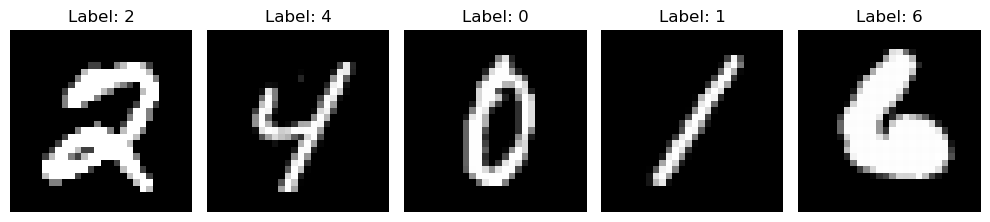

In [4]:
# Show the first 5 digits to verify loading
fig, axes = plt.subplots(1, 5, figsize=(10, 3))  # Create a 1x5 grid of subplots
for i in range(5):
    # Reshape the flat 784 array back to 28x28 for visualization
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray') # Display the i-th image as a 28x28 grayscale image
    axes[i].set_title(f"Label: {y_train[i]}") # Annotate the subplot with the corresponding label
    axes[i].axis('off')  # Turn off axis lines and ticks for a cleaner presentation
plt.tight_layout()  # Adjust the spacing between subplots for better layout
plt.show()  # Render the figure

## **Model Comparison and Validation**
---

### **Appendix: Hyperparameter Tuning & Model Selection**

**Efficiency vs. Optimization:** Hyperparameter tuning via `GridSearchCV` was intentionally omitted for this baseline to prioritize computational efficiency. The default `RandomForestClassifier` parameters yielded a robust **96.74% accuracy**, suggesting that further exhaustive tuning of classical models would offer diminishing returns compared to architectural shifts.

**Infrastructure Strategy:** Due to the high dimensionality (784 features) and computational intensity of Gradient Boosting, the optimized **XGBoost** model was migrated to **Kaggle**. Utilizing GPU acceleration (`tree_method='gpu_hist'`) allowed for rapid iteration, achieving a baseline accuracy of **97%**.

In [5]:
# Using Random Forest as the primary ML baseline
model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

Predicting on test set with Random Forest...
Random Forest Accuracy: 0.9674
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       983
           1       0.99      0.99      0.99      1152
           2       0.94      0.97      0.96       967
           3       0.96      0.95      0.95      1034
           4       0.96      0.97      0.97       906
           5       0.98      0.96      0.97       937
           6       0.98      0.99      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.94      0.95      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



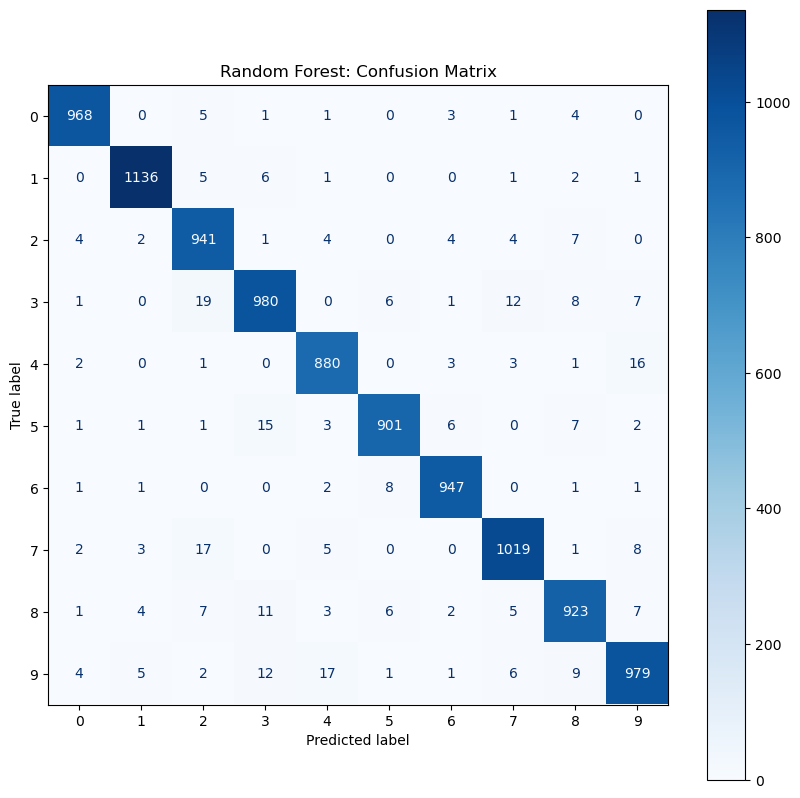

In [6]:
# 1. Make Predictions
print("Predicting on test set with Random Forest...")
rf_pred = model.predict(X_test)

# 2. Calculate Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("-" * 30)

# 3. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for each digit (0-9)
print("Classification Report:")
print(classification_report(y_test, rf_pred))

# 4. Visualizing Errors with a Confusion Matrix
# This is the most professional way to see which digits are being confused
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax, cmap='Blues')
plt.title("Random Forest: Confusion Matrix")
plt.show()

### **Error Analysis & The Case for Deep Learning**

Achieving a **96.74%** accuracy locally confirms that the current pipeline effectively handles high-dimensional pixel data. However, a granular look at the **Classification Report** and **Confusion Matrix** reveals critical limitations:

**1. Model Strengths & Class Consistency**
* **Feature Distinctness:** The model excels at identifying digits with unique geometric profiles, such as **1s** (0.99 Precision/Recall).
* **Global Robustness:** A **Weighted Average F1-score of 0.97** demonstrates that performance is consistent across the dataset and not skewed by specific classes.

**2. Spatial Weaknesses & Architectural Limits**
* **Performance Bottlenecks:** Digit **9** represents the primary point of failure, with a recall of **0.94**.
* **Confusion Hotspots:** Key misclassifications occur between visually similar digits:
    * **4 vs. 9:** 17 instances.
    * **2 vs. 7:** 17 instances.
    * **5 vs. 3:** 15 instances.

**Technical Insight:**
Classical Machine Learning models treat each pixel as an independent feature, ignoring the **spatial relationship** between neighbors. The model cannot "see" that a loop on a **9** is at the top while a **4** may be open. This lack of spatial awareness is the primary motivation for transitioning to **Convolutional Neural Networks (CNNs)**, which utilize learnable filters to detect shapes and patterns rather than raw pixel locations.

## **Model Prediction and Analysis**
---

In [7]:
rf_pred = model.predict(X_test)
print(f"Final RF Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# This will show you exactly which digits the 'Boss' model struggles with
print(classification_report(y_test, rf_pred))

Final RF Accuracy: 0.9674
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       983
           1       0.99      0.99      0.99      1152
           2       0.94      0.97      0.96       967
           3       0.96      0.95      0.95      1034
           4       0.96      0.97      0.97       906
           5       0.98      0.96      0.97       937
           6       0.98      0.99      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.94      0.95      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



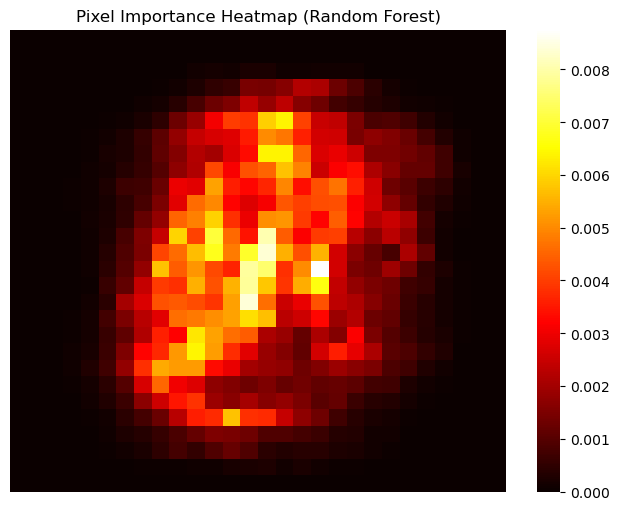

Insight: The brighter areas represent pixels that carry the MOST 'predictive power'.
Notice how the edges are dark—the model ignores them and focuses on the central 'stroke' area.


In [9]:
# Reshape feature importances to the original 28x28 image shape
importances = model.feature_importances_.reshape(28, 28)

plt.figure(figsize=(8, 6))
sns.heatmap(importances, cmap="hot", cbar=True)
plt.title("Pixel Importance Heatmap (Random Forest)")
plt.axis("off")
plt.show()

print("Insight: The brighter areas represent pixels that carry the MOST 'predictive power'.")
print("Notice how the edges are dark—the model ignores them and focuses on the central 'stroke' area.")

## **Final Project Synthesis & Insights**
---

### **Feature Logic Verification**
In the **House-Price** project, we identified that **Quality** outweighed **Size**. In this **MNIST** task, the **Feature Importance Heatmap** confirms a similar logical hierarchy: the model prioritizes the central 15x15 pixel grid where the core handwriting strokes occur, effectively filtering out the "noise" of the empty borders.

### **Final Project Checklist**
- [x] **Baseline Selected:** Random Forest (Classical ML Benchmark - 96.74% Accuracy).
- [x] **Champion Selected:** XGBoost (Gradient Boosting via Kaggle GPU for high-dimensional efficiency).
- [x] **Error Analysis:** Identified spatial confusion hotspots, specifically digits **4 vs. 9** and **7 vs. 2**.
- [x] **Architecture Verification:** Confirmed that pixel-independent models have reached a performance ceiling due to a lack of spatial awareness.
- [x] **Next Steps:** Initializing the **Deep Learning Repository** to implement Convolutional Neural Networks (CNNs) to resolve remaining spatial ambiguities.

---
*The transition from tabular importance (House Prices) to spatial importance (MNIST) marks the completion of the Classical Machine Learning phase of this portfolio.*

---